# Trust-Region Methods on Nonconvex Objectives

Trust-region methods solve local quadratic models
$$
\min_{\|p\|\le \Delta_k}\ m_k(p)=f(x_k)+g_k^\top p+\tfrac12 p^\top B_k p,
$$
and adapt radius $\Delta_k$ using agreement ratio between actual and predicted decrease.


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/trust-region-methods") if Path("python/trust-region-methods").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


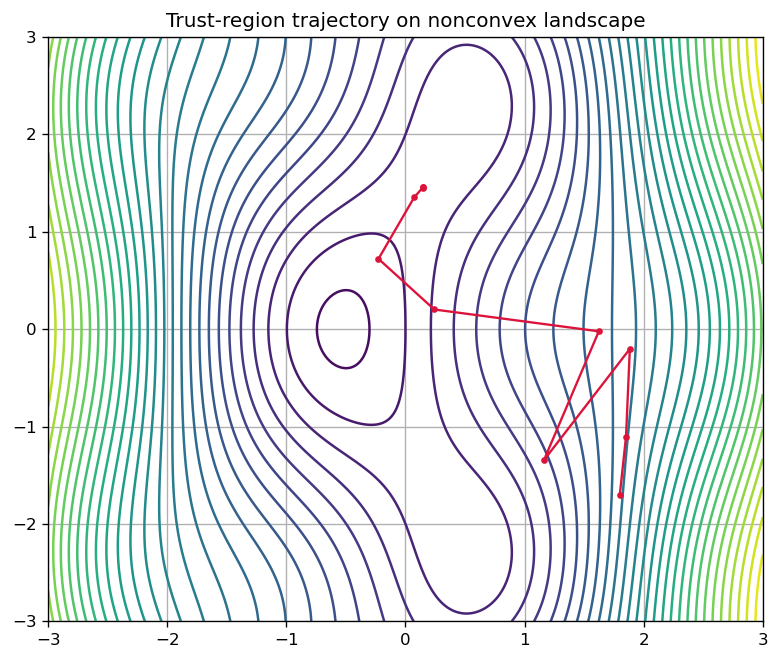

In [2]:
def f(x):
    x1, x2 = x
    return 0.5*(4*x1**2 + 0.4*x2**2) + 2*np.sin(1.7*x1)*np.cos(1.2*x2)

def grad(x):
    x1, x2 = x
    return np.array([
        4*x1 + 3.4*np.cos(1.7*x1)*np.cos(1.2*x2),
        0.4*x2 - 2.4*np.sin(1.7*x1)*np.sin(1.2*x2)
    ])

def hess_fd(x, h=1e-4):
    n = len(x)
    H = np.zeros((n,n))
    for i in range(n):
        e = np.zeros(n); e[i]=1
        H[:, i] = (grad(x + h*e) - grad(x - h*e))/(2*h)
    return H

x = np.array([1.8, -1.7], dtype=float)
Delta = 0.6
traj=[x.copy()]

for _ in range(70):
    g = grad(x)
    B = hess_fd(x)
    # unconstrained Newton-like step then clipped to ball
    try:
        p = -np.linalg.solve(B + 1e-4*np.eye(2), g)
    except np.linalg.LinAlgError:
        p = -g
    nrm = np.linalg.norm(p)
    if nrm > Delta:
        p = p * (Delta / (nrm + 1e-12))

    mk0 = f(x)
    mkp = mk0 + g@p + 0.5*p@(B@p)
    ared = f(x) - f(x+p)
    pred = mk0 - mkp
    rho = ared / (pred + 1e-12)

    if rho > 0.1:
        x = x + p
        traj.append(x.copy())
    if rho > 0.75:
        Delta = min(1.5*Delta, 1.4)
    elif rho < 0.25:
        Delta = max(0.5*Delta, 0.05)

traj = np.array(traj)
X1 = np.linspace(-3, 3, 280)
X2 = np.linspace(-3, 3, 280)
XX1, XX2 = np.meshgrid(X1, X2)
ZZ = 0.5*(4*XX1**2 + 0.4*XX2**2) + 2*np.sin(1.7*XX1)*np.cos(1.2*XX2)

fig, ax = plt.subplots(figsize=(6.6,5.6))
ax.contour(XX1, XX2, ZZ, levels=32, cmap="viridis")
ax.plot(traj[:,0], traj[:,1], "-o", ms=3, lw=1.4, color="crimson")
ax.set_title("Trust-region trajectory on nonconvex landscape")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- J. Nocedal, S. J. Wright, *Numerical Optimization*, Springer, 2006.
- A. R. Conn, N. I. M. Gould, P. L. Toint, *Trust Region Methods*, SIAM, 2000.
- Y. Yuan, "Recent Advances in Trust Region Algorithms", Math. Programming, 2015.
